# Step 2: Exploratory Data Analysis
Visualize churn patterns and relationships

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/bank_churn_clean.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


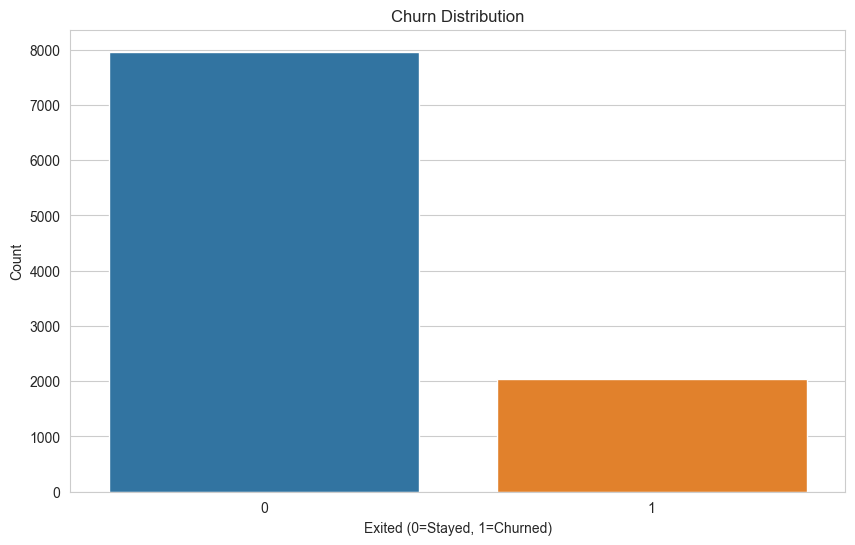

Overall churn rate: 20.37%


In [3]:
# Churn distribution
plt.figure()
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Count')
plt.savefig('../outputs/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

churn_rate = df['Exited'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

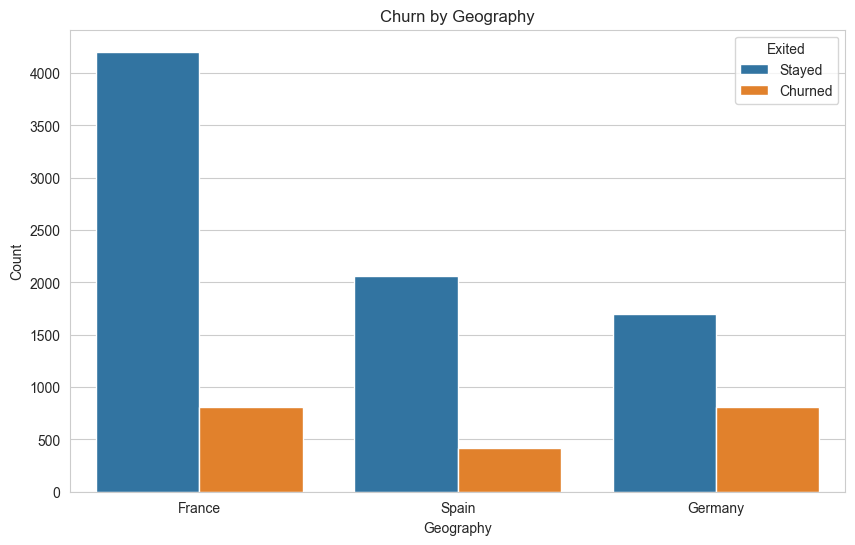

In [4]:
# Churn by Geography
plt.figure()
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Churned'])
plt.savefig('../outputs/churn_by_geography.png', dpi=300, bbox_inches='tight')
plt.show()

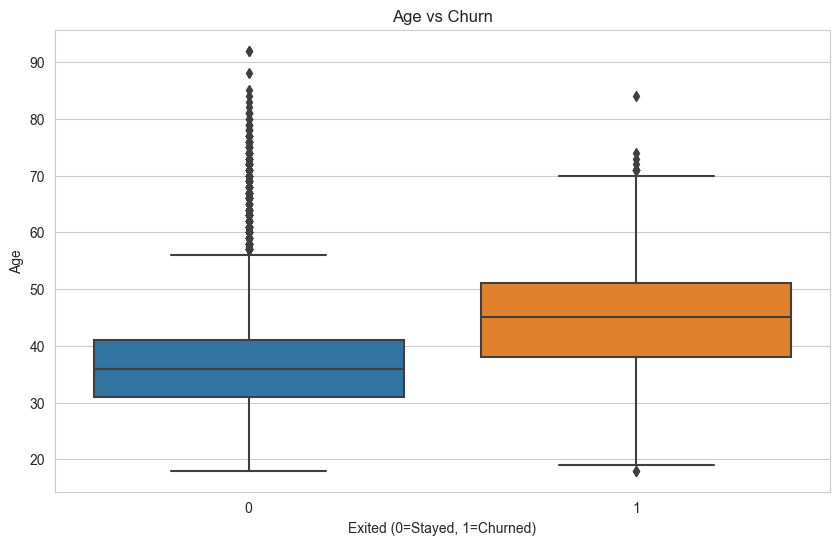

In [5]:
# Age vs Churn
plt.figure()
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age vs Churn')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Age')
plt.savefig('../outputs/age_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

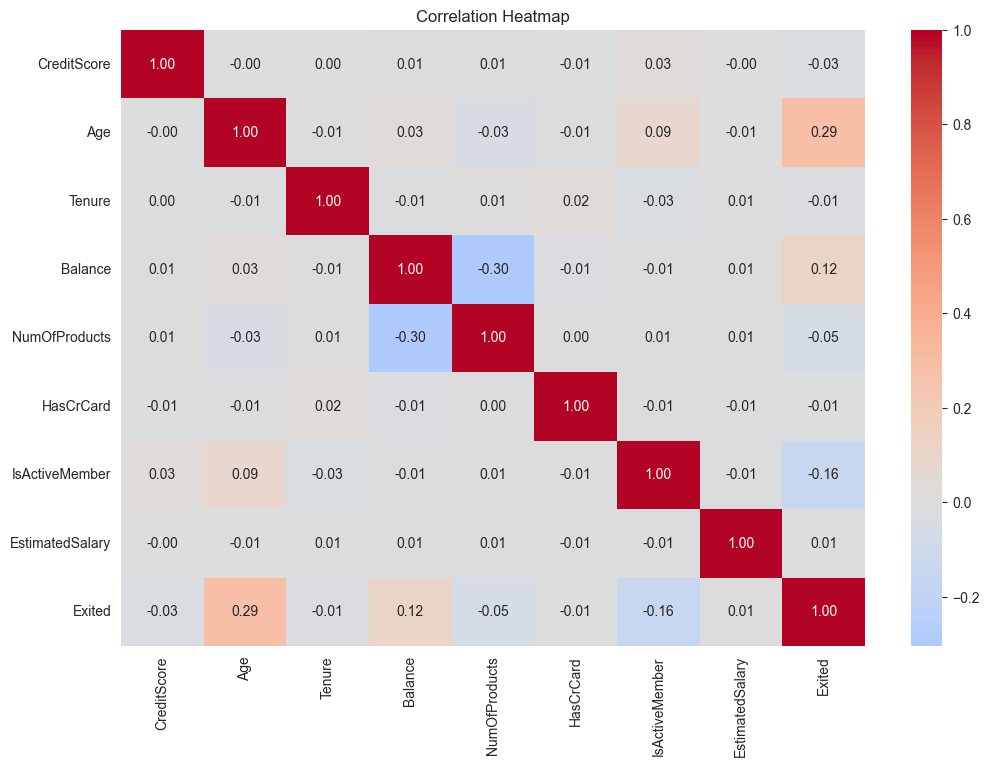

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('../outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Additional insights
print("\nChurn rate by Geography:")
print(df.groupby('Geography')['Exited'].mean().sort_values(ascending=False))

print("\nChurn rate by Gender:")
print(df.groupby('Gender')['Exited'].mean().sort_values(ascending=False))

print("\nChurn rate by Number of Products:")
print(df.groupby('NumOfProducts')['Exited'].mean().sort_values(ascending=False))


Churn rate by Geography:
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

Churn rate by Gender:
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

Churn rate by Number of Products:
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64
